# 2. Patching benchmark notebook

这个 notebook 只检查 `patching.py`。

核心问题：

- patch 点是不是确实落在费米面上
- `orbital_weight` 是否归一化
- `k_red` 是否被正确 wrap 到第一 BZ
- `v_F` 是否大致垂直于 patch 曲线
- 改变 `grid_size` / `Npatch` 时，patching 是否稳定

这里我默认用最简单的 **spinless vanilla kagome** 先检查 patching 本身。


In [1]:
import os, sys, math, cmath
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/mnt/data')

from noninteracting import KagomeNagaosa, KagomeStaggerFlux, KagomeKaneMeleSOC
from patching import FSPatcher
from interaction import BareExtendedHubbard
from channels import ChannelDecomposer

RESULTS = []

def record(name, passed, detail='', value=None):
    RESULTS.append({
        'test': name,
        'passed': bool(passed),
        'detail': str(detail),
        'value': value,
    })

def check(name, cond, detail_ok='', detail_fail='', value=None):
    if cond:
        record(name, True, detail_ok, value)
    else:
        record(name, False, detail_fail, value)


def summarize_results():
    n_pass = sum(r['passed'] for r in RESULTS)
    n_fail = len(RESULTS) - n_pass
    print('='*90)
    print(f'Total tests: {len(RESULTS)} | PASS: {n_pass} | FAIL: {n_fail}')
    print('='*90)
    for i, r in enumerate(RESULTS, 1):
        flag = 'PASS' if r['passed'] else 'FAIL'
        print(f"[{i:02d}] {flag:4s} | {r['test']}")
        if r['detail']:
            print('     ', r['detail'])
        if r['value'] is not None:
            print('     value =', r['value'])
    print('='*90)
    return n_fail


In [2]:
# 你可以改这里
model = KagomeNagaosa(parameters={'t': 1.0, 'phi': 0.0}, spin=False)
mu = model.EF_from_filling(5/12, N=100, tol=1e-4)
print('mu =', mu)


mu = -3.0083462602747215e-17


In [3]:
# 建两套 patching：一套主设置，一套稍微更密一点做稳定性比较
patcher_main = FSPatcher(
    model=model,
    band_index=1,
    mu=mu,
    Npatch=24,
    grid_size=220,
    verbose=False,
)
patcher_ref = FSPatcher(
    model=model,
    band_index=1,
    mu=mu,
    Npatch=24,
    grid_size=320,
    verbose=False,
)

patchset_main = patcher_main.build()
patchset_ref  = patcher_ref.build()

print('main Npatch =', patchset_main.Npatch)
print('ref  Npatch =', patchset_ref.Npatch)


main Npatch = 24
ref  Npatch = 24


In [4]:
# 1) energy-on-FS check
energies = np.array([p.energy for p in patchset_main.patches], dtype=float)
errs = np.abs(energies - patchset_main.mu)

check(
    'patch energy max error',
    errs.max() < 1e-6,
    detail_ok=f'max|E-mu|={errs.max():.3e}, mean={errs.mean():.3e}',
    detail_fail=f'patch projection onto FS is poor: max|E-mu|={errs.max():.3e}, mean={errs.mean():.3e}',
    value={'max': float(errs.max()), 'mean': float(errs.mean())},
)


In [5]:
# 2) orbital weight normalization
norm_errs = []
for p in patchset_main.patches:
    norm_errs.append(abs(np.sum(p.orbital_weight) - 1.0))
norm_errs = np.array(norm_errs)

check(
    'orbital weight normalization',
    norm_errs.max() < 1e-12,
    detail_ok=f'max|sum(w)-1|={norm_errs.max():.3e}',
    detail_fail=f'orbital weights are not normalized, max err={norm_errs.max():.3e}',
    value=float(norm_errs.max()),
)


In [6]:
# 3) k_red range check
kreds = np.array([p.k_red for p in patchset_main.patches], dtype=float)
min_red = kreds.min()
max_red = kreds.max()
cond = (min_red > -1e-10) and (max_red < 1 + 1e-10)
check(
    'reduced coordinates wrapped into first BZ',
    cond,
    detail_ok=f'min={min_red:.3e}, max={max_red:.3e}',
    detail_fail=f'k_red out of range: min={min_red:.3e}, max={max_red:.3e}',
    value={'min': float(min_red), 'max': float(max_red)},
)


In [7]:
# 4) vF roughly normal to local contour tangent
# 用相邻 patch 的差分构造 tangent，再看 tangent · vF 是否接近 0
ks = np.array([p.k_cart for p in patchset_main.patches], dtype=float)
vf = np.array([p.vF for p in patchset_main.patches], dtype=float)
N = len(ks)
normality = []
for i in range(N):
    km = ks[(i-1)%N]
    kp = ks[(i+1)%N]
    tangent = kp - km
    tn = np.linalg.norm(tangent)
    vn = np.linalg.norm(vf[i])
    if tn < 1e-14 or vn < 1e-14:
        continue
    c = abs(np.dot(tangent, vf[i]))/(tn*vn)
    normality.append(c)
normality = np.array(normality)
check(
    'vF approximately normal to FS contour',
    normality.mean() < 0.2,
    detail_ok=f'mean |cos(theta)| = {normality.mean():.3e}, max = {normality.max():.3e}',
    detail_fail=f'vF may not be normal to FS contour: mean |cos(theta)| = {normality.mean():.3e}, max = {normality.max():.3e}',
    value={'mean_abs_cos': float(normality.mean()), 'max_abs_cos': float(normality.max())},
)


In [8]:
# 5) simple patch-to-patch arc uniformity (not strict theorem, but catches broken ordering / jumps)
step_lengths = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
ratio = step_lengths.max()/step_lengths.min()
check(
    'patch spacing not wildly irregular',
    ratio < 5.0,
    detail_ok=f'max/min neighbor spacing = {ratio:.3f}',
    detail_fail=f'patch ordering may be problematic, max/min spacing = {ratio:.3f}',
    value=float(ratio),
)


In [9]:
# 6) stability against finer grid size
# 因为 patch id 可能整体循环平移，所以这里只比较“每个点到参考 patch 集最近点”的距离
ks_ref = np.array([p.k_cart for p in patchset_ref.patches], dtype=float)
dists = []
for k in ks:
    d = np.min(np.linalg.norm(ks_ref - k, axis=1))
    dists.append(d)
dists = np.array(dists)
check(
    'patch locations stable vs grid refinement',
    dists.mean() < 5e-2,
    detail_ok=f'mean nearest distance = {dists.mean():.3e}, max = {dists.max():.3e}',
    detail_fail=f'patches drift strongly when grid_size changes: mean = {dists.mean():.3e}, max = {dists.max():.3e}',
    value={'mean': float(dists.mean()), 'max': float(dists.max())},
)


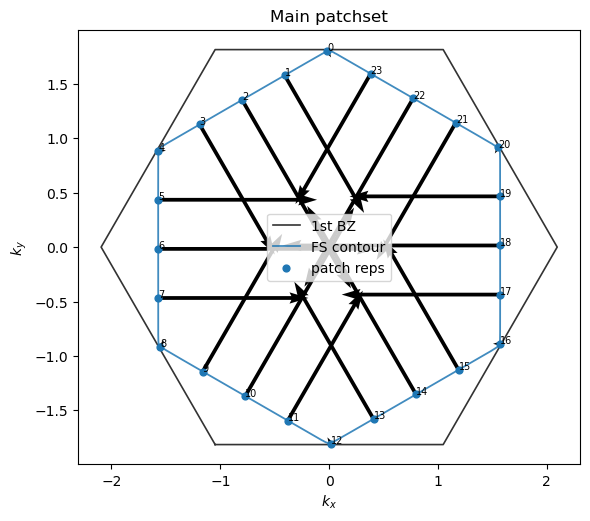

In [10]:
# Optional visualization
from patching import plot_patchset
fig, ax = plt.subplots(figsize=(6,6))
plot_patchset(patchset_main, ax=ax, show_contour=True, show_velocity=True, show_bz=True)
ax.set_title('Main patchset')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [11]:
summarize_results()


Total tests: 6 | PASS: 6 | FAIL: 0
[01] PASS | patch energy max error
      max|E-mu|=5.019e-16, mean=1.307e-16
     value = {'max': 5.019282480684387e-16, 'mean': 1.3065910253175809e-16}
[02] PASS | orbital weight normalization
      max|sum(w)-1|=1.110e-16
     value = 1.1102230246251565e-16
[03] PASS | reduced coordinates wrapped into first BZ
      min=5.229e-03, max=9.943e-01
     value = {'min': 0.005229324146419634, 'max': 0.9943377314100639}
[04] PASS | vF approximately normal to FS contour
      mean |cos(theta)| = 1.255e-01, max = 4.837e-01
     value = {'mean_abs_cos': 0.1254597361923, 'max_abs_cos': 0.4837356576867289}
[05] PASS | patch spacing not wildly irregular
      max/min neighbor spacing = 1.006
     value = 1.0060862862986382
[06] PASS | patch locations stable vs grid refinement
      mean nearest distance = 1.305e-03, max = 2.583e-03
     value = {'mean': 0.001304679461506075, 'max': 0.002583375460241233}


0